In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/results.csv")

INFO ABOUT DATASET

In [4]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [5]:
df.shape

(49437, 9)

In [6]:
df.describe

<bound method NDFrame.describe of              date home_team   away_team  home_score  away_score  \
0      1872-11-30  Scotland     England         0.0         0.0   
1      1873-03-08   England    Scotland         4.0         2.0   
2      1874-03-07  Scotland     England         2.0         1.0   
3      1875-03-06   England    Scotland         2.0         2.0   
4      1876-03-04  Scotland     England         3.0         0.0   
...           ...       ...         ...         ...         ...   
49432  2026-06-27    Jordan   Argentina         NaN         NaN   
49433  2026-06-27  Colombia    Portugal         NaN         NaN   
49434  2026-06-27  DR Congo  Uzbekistan         NaN         NaN   
49435  2026-06-27    Panama     England         NaN         NaN   
49436  2026-06-27   Croatia       Ghana         NaN         NaN   

           tournament             city        country  neutral  
0            Friendly          Glasgow       Scotland    False  
1            Friendly          

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49437 entries, 0 to 49436
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49437 non-null  str    
 1   home_team   49437 non-null  str    
 2   away_team   49437 non-null  str    
 3   home_score  49365 non-null  float64
 4   away_score  49365 non-null  float64
 5   tournament  49437 non-null  str    
 6   city        49437 non-null  str    
 7   country     49437 non-null  str    
 8   neutral     49437 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [8]:
df.sample(10)

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
11128,1977-09-25,Tunisia,Nigeria,0.0,0.0,FIFA World Cup qualification,Tunis,Tunisia,False
6927,1967-01-22,Honduras,Guatemala,1.0,1.0,Friendly,Tegucigalpa,Honduras,False
13739,1983-07-18,Hong Kong,Thailand,1.0,1.0,Great Wall Cup,Beijing,China,True
37503,2013-11-19,Russia,South Korea,2.0,1.0,Friendly,Dubai,United Arab Emirates,True
41089,2017-10-09,Ukraine,Croatia,0.0,2.0,FIFA World Cup qualification,Kyiv,Ukraine,False
41737,2018-09-06,Latvia,Andorra,0.0,0.0,UEFA Nations League,Riga,Latvia,False
21189,1996-06-26,France,Czech Republic,0.0,0.0,UEFA Euro,Manchester,England,True
10475,1976-03-26,Qatar,Saudi Arabia,1.0,0.0,Gulf Cup,Doha,Qatar,False
27667,2003-10-15,Syria,Sri Lanka,5.0,0.0,AFC Asian Cup qualification,Damascus,Syria,False
33317,2009-09-09,Romania,Austria,1.0,1.0,FIFA World Cup qualification,Bucharest,Romania,False


CLEANING THE DATA


In [9]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

ARRANGING DATE WISE

In [12]:
df["date"] = pd.to_datetime(df["date"])

In [13]:
df["date"].min()
df["date"].max()

Timestamp('2026-06-27 00:00:00')

DISCARDING VERY OLD DATA

In [14]:
df = df[df["date"].dt.year >= 2010]

In [15]:
df.shape

(15849, 9)

VISUAL REPRESENTATION

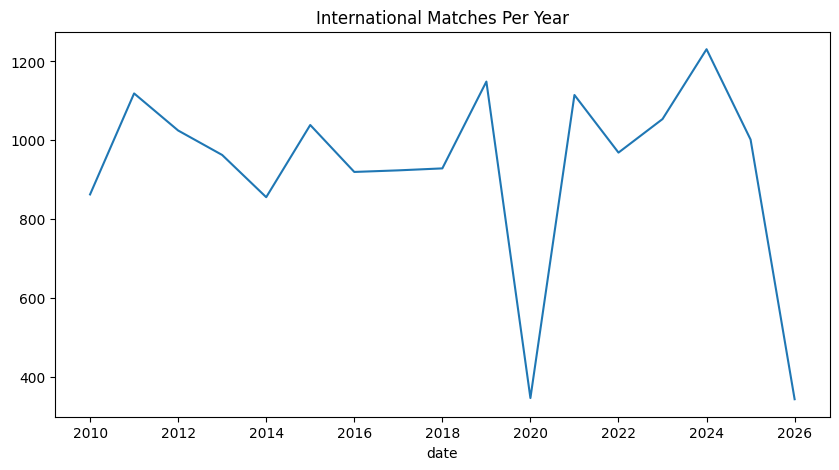

In [16]:
matches_per_year = df.groupby(df["date"].dt.year).size()

matches_per_year.plot(figsize=(10,5))
plt.title("International Matches Per Year")
plt.show()

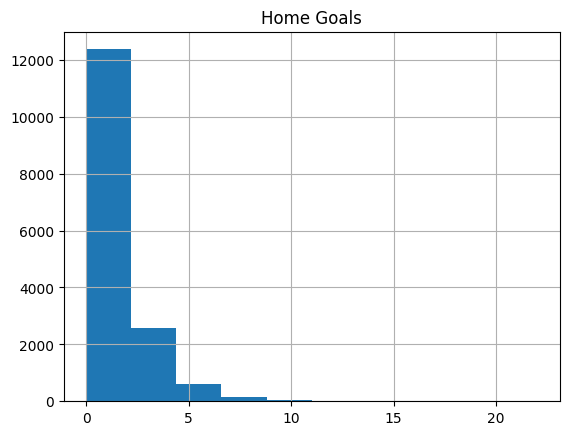

In [17]:
df["home_score"].hist(bins=10)
plt.title("Home Goals")
plt.show()

In [18]:
teams = pd.concat([df["home_team"],df["away_team"]])

teams.value_counts().head(20)

Mexico           286
United States    257
Qatar            251
Iraq             238
Jordan           237
Panama           237
South Korea      231
Costa Rica       231
Saudi Arabia     230
Japan            229
Bahrain          227
Oman             225
Argentina        217
France           215
Germany          215
Brazil           215
Spain            214
South Africa     212
Honduras         212
Tunisia          210
Name: count, dtype: int64

SAVING NEW DATA


In [19]:
df.to_csv("../data/clean_results.csv",index=False)